In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

from DenoisingDiffusionModel import DiffusionModel

## Setup

In [2]:
device = torch.device("mps")

In [3]:
# must match the values used in DDPM_Trainer.py
T_N       = 1024
T_DIM     = 64
HEADS     = 8
MODEL_DIM = 128
LAYERS    = 1

Model = DiffusionModel(3, T_N, T_DIM, HEADS, MODEL_DIM, LAYERS, device).to(device)

In [4]:
Checkpoint = torch.load("Checkpoint_Meta_Diffusion.pt", map_location=device)

for v , k in enumerate(Checkpoint["EMA_Weights"]):
    print(k)

alpha_bars
UNET.TimeEmbd.mlp.0.weight
UNET.TimeEmbd.mlp.0.bias
UNET.TimeEmbd.mlp.2.weight
UNET.TimeEmbd.mlp.2.bias
UNET.M1.T1.weight
UNET.M1.T1.bias
UNET.M1.C1.weight
UNET.M1.C1.bias
UNET.M1.C2.weight
UNET.M1.C2.bias
UNET.M2.T1.weight
UNET.M2.T1.bias
UNET.M2.C1.weight
UNET.M2.C1.bias
UNET.M2.C2.weight
UNET.M2.C2.bias
UNET.T2.NORM1.weight
UNET.T2.NORM1.bias
UNET.T2.C1.weight
UNET.T2.C1.bias
UNET.T2.selfAtten.0.V1.weight
UNET.T2.selfAtten.0.Q1.weight
UNET.T2.selfAtten.0.K1.weight
UNET.T2.selfAtten.0.O1.weight
UNET.T2.MLP.0.0.weight
UNET.T2.MLP.0.0.bias
UNET.T2.MLP.0.2.weight
UNET.T2.MLP.0.2.bias
UNET.T2.C2.weight
UNET.T2.C2.bias
UNET.M3.T1.weight
UNET.M3.T1.bias
UNET.M3.C1.weight
UNET.M3.C1.bias
UNET.M3.C2.weight
UNET.M3.C2.bias
UNET.T3.NORM1.weight
UNET.T3.NORM1.bias
UNET.T3.C1.weight
UNET.T3.C1.bias
UNET.T3.selfAtten.0.V1.weight
UNET.T3.selfAtten.0.Q1.weight
UNET.T3.selfAtten.0.K1.weight
UNET.T3.selfAtten.0.O1.weight
UNET.T3.MLP.0.0.weight
UNET.T3.MLP.0.0.bias
UNET.T3.MLP.0.2.weight
UN

In [5]:
Model.load_state_dict(Checkpoint["EMA_Weights"])
Model.eval()
print(f"Loaded checkpoint from epoch {Checkpoint['Epoch']}")

Loaded checkpoint from epoch 800


## Generated samples

Reverse diffusion from pure noise. With T=1024 this is 1024 sequential UNet passes, so a 64-image grid takes a while on a small GPU — lower `n` for a quick look.

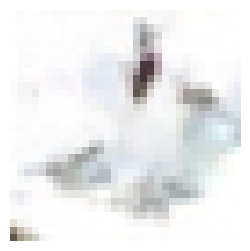

In [6]:
with torch.no_grad():
    fakes = Model.sample(1, channels=3, size=32)

img = fakes[0].cpu().numpy().transpose(1, 2, 0)
img = (img + 1) / 2          # [-1,1] -> [0,1], matching your training normalization
img = np.clip(img, 0, 1)

plt.figure(figsize=(3,3))
plt.imshow(img, interpolation='nearest')
plt.axis('off')
plt.show()

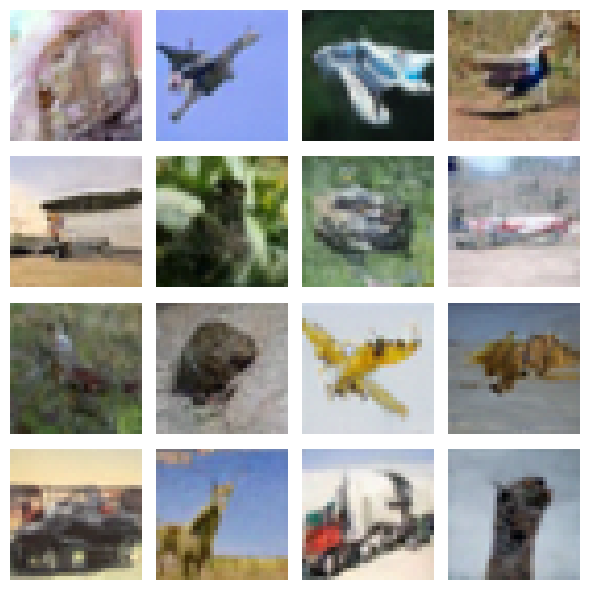

In [ ]:
with torch.no_grad():
    fakes = Model.sample(64, channels=3, size=32)

fig, axes = plt.subplots(8, 8, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    img = fakes[i].cpu().numpy().transpose(1, 2, 0)
    img = (img + 1) / 2          # [-1,1] -> [0,1], matching your training normalization
    img = np.clip(img, 0, 1)
    ax.imshow(img, interpolation='nearest')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Training loss

In [8]:


for i in range(16):
    f = fakes[i]
    print(f"img {i}: min={f.min():.3f} max={f.max():.3f} mean={f.mean():.3f} std={f.std():.3f}")

img 0: min=-0.921 max=0.632 mean=-0.226 std=0.308
img 1: min=-0.753 max=0.483 mean=-0.266 std=0.207
img 2: min=-0.990 max=0.843 mean=-0.276 std=0.447
img 3: min=-0.883 max=0.917 mean=0.066 std=0.453
img 4: min=-1.000 max=0.946 mean=-0.424 std=0.354
img 5: min=-0.723 max=1.000 mean=0.126 std=0.428
img 6: min=-1.000 max=1.000 mean=-0.311 std=0.405
img 7: min=-0.865 max=0.769 mean=0.049 std=0.390
img 8: min=-0.688 max=1.000 mean=0.713 std=0.448
img 9: min=-0.888 max=1.000 mean=-0.176 std=0.382
img 10: min=-0.934 max=0.286 mean=-0.626 std=0.208
img 11: min=-0.987 max=0.673 mean=-0.182 std=0.334
img 12: min=-0.886 max=0.872 mean=0.085 std=0.510
img 13: min=-0.855 max=0.919 mean=0.106 std=0.427
img 14: min=-0.945 max=0.784 mean=-0.493 std=0.264
img 15: min=-0.922 max=0.858 mean=0.125 std=0.373


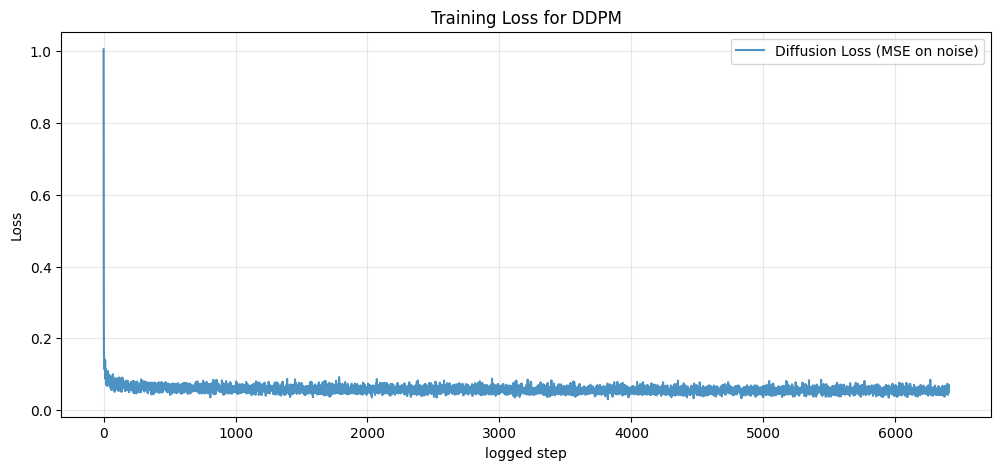

In [9]:
Losses = np.array([l for l in Checkpoint["Losses"]])

plt.figure(figsize=(12, 5))
plt.plot(Losses, label='Diffusion Loss (MSE on noise)', alpha=0.8)
plt.xlabel('logged step')
plt.ylabel('Loss')
plt.title('Training Loss for DDPM')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()